In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import os
import sys
import torch

print("="*80)
print(" ENVIRONMENT CHECK")
print("="*80)
print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

if os.path.exists('/kaggle/input'):
    print(f"\n Kaggle datasets:")
    for d in os.listdir('/kaggle/input'):
        print(f"   • {d}")
print("="*80)


 ENVIRONMENT CHECK
Python: 3.12.12
PyTorch: 2.8.0+cu126
CUDA: True
GPU: Tesla T4
Memory: 15.6 GB

 Kaggle datasets:
   • indianfooddataset


In [ ]:
!pip install -q timm
print(" Packages installed!")

 Packages installed!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import shutil
import zipfile
from collections import defaultdict, Counter
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
print(" All libraries imported!")

 All libraries imported!


In [ ]:
class Config:

    DATASET_NAME = 'indianfooddataset'

    # Paths
    INPUT_DIR = f'/kaggle/input/{DATASET_NAME}'
    CLEANED_DIR = '/kaggle/working/cleaned_data'
    MODEL_DIR = '/kaggle/working/models'
    PLOT_DIR = '/kaggle/working/plots'

    # Training params
    NUM_CLASSES = 100
    IMAGE_SIZE = 224
    BATCH_SIZE = 32
    EPOCHS = 50  # Set to 5 for testing
    LR = 1e-4
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Model
    BACKBONE = 'resnet50'

    os.makedirs(CLEANED_DIR, exist_ok=True)
    os.makedirs(MODEL_DIR, exist_ok=True)
    os.makedirs(PLOT_DIR, exist_ok=True)

cfg = Config()
print(f" Config set | Device: {cfg.DEVICE} | Dataset: {cfg.DATASET_NAME}")


 Config set | Device: cuda | Dataset: indianfooddataset


In [ ]:
print("="*80)
print(" EXTRACTING ZIP FILE")
print("="*80)

items = os.listdir(cfg.INPUT_DIR)
zip_files = [f for f in items if f.endswith('.zip')]

if zip_files:
    zip_path = os.path.join(cfg.INPUT_DIR, zip_files[0])
    extract_dir = '/kaggle/working/extracted'

    print(f"Found ZIP: {zip_files[0]}")
    print(f"Size: {os.path.getsize(zip_path)/1e9:.2f} GB")
    print("Extracting... (this may take 5-10 minutes for 20GB)")

    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(extract_dir)

    # Find data folder
    contents = os.listdir(extract_dir)
    if len(contents) == 1 and os.path.isdir(os.path.join(extract_dir, contents[0])):
        DATA_DIR = os.path.join(extract_dir, contents[0])
    else:
        DATA_DIR = extract_dir

    print(f" Extracted to: {DATA_DIR}")
else:
    # Direct folder
    folders = [f for f in items if os.path.isdir(os.path.join(cfg.INPUT_DIR, f))]
    DATA_DIR = os.path.join(cfg.INPUT_DIR, folders[0]) if folders else cfg.INPUT_DIR
    print(f" Using folder: {DATA_DIR}")

print("="*80)

 EXTRACTING ZIP FILE
 Using folder: /kaggle/input/indianfooddataset/CompressedDataset



 ANALYZING DATASET...
Classes: 100


Analyzing: 100%|██████████| 100/100 [00:01<00:00, 54.19it/s]



 SUMMARY:
Total classes: 100
Total images: 4,577
Total size: 0.06 GB
Avg per class: 45.8 images
Range: 7 - 83


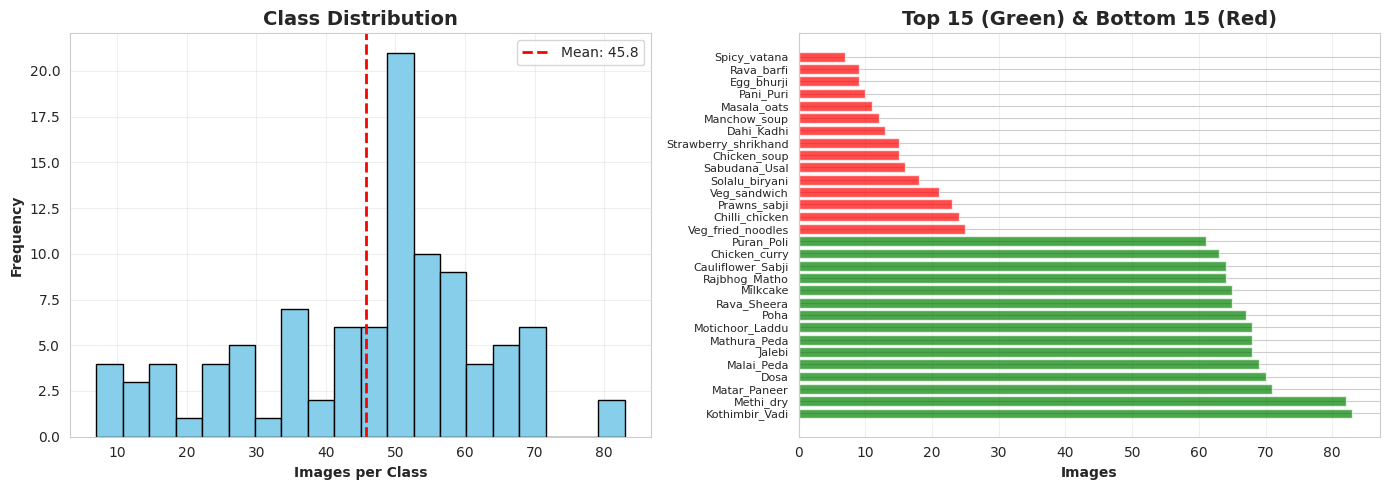

 Saved: 01_distribution.png


In [ ]:
print("\n ANALYZING DATASET...")

classes = sorted([f for f in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, f))])
print(f"Classes: {len(classes)}")

class_info = []
for cls in tqdm(classes, desc="Analyzing"):
    cls_path = os.path.join(DATA_DIR, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png','.jpg','.jpeg','.bmp'))]
    size = sum(os.path.getsize(os.path.join(cls_path, i)) for i in imgs) / 1e6
    class_info.append({'class': cls, 'images': len(imgs), 'size_mb': size})

df = pd.DataFrame(class_info)

print(f"\n SUMMARY:")
print(f"Total classes: {len(df)}")
print(f"Total images: {df['images'].sum():,}")
print(f"Total size: {df['size_mb'].sum()/1000:.2f} GB")
print(f"Avg per class: {df['images'].mean():.1f} images")
print(f"Range: {df['images'].min()} - {df['images'].max()}")

#  VIZ 1: Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['images'], bins=20, color='skyblue', edgecolor='black')
axes[0].axvline(df['images'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['images'].mean():.1f}")
axes[0].set_xlabel('Images per Class', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Class Distribution', fontweight='bold', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

df_sort = df.sort_values('images', ascending=False)
top_bot = pd.concat([df_sort.head(15), df_sort.tail(15)])
colors = ['green']*15 + ['red']*15
axes[1].barh(range(len(top_bot)), top_bot['images'], color=colors, alpha=0.7)
axes[1].set_yticks(range(len(top_bot)))
axes[1].set_yticklabels(top_bot['class'], fontsize=8)
axes[1].set_xlabel('Images', fontweight='bold')
axes[1].set_title('Top 15 (Green) & Bottom 15 (Red)', fontweight='bold', fontsize=14)
axes[1].grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{cfg.PLOT_DIR}/01_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: 01_distribution.png")


 SCANNING FOR CORRUPTED IMAGES...


Scanning: 100%|██████████| 100/100 [00:15<00:00,  6.55it/s]



 SCAN RESULTS:
Total: 4,577
Valid: 4,577 (100.0%)
Corrupted: 0 (0.0%)


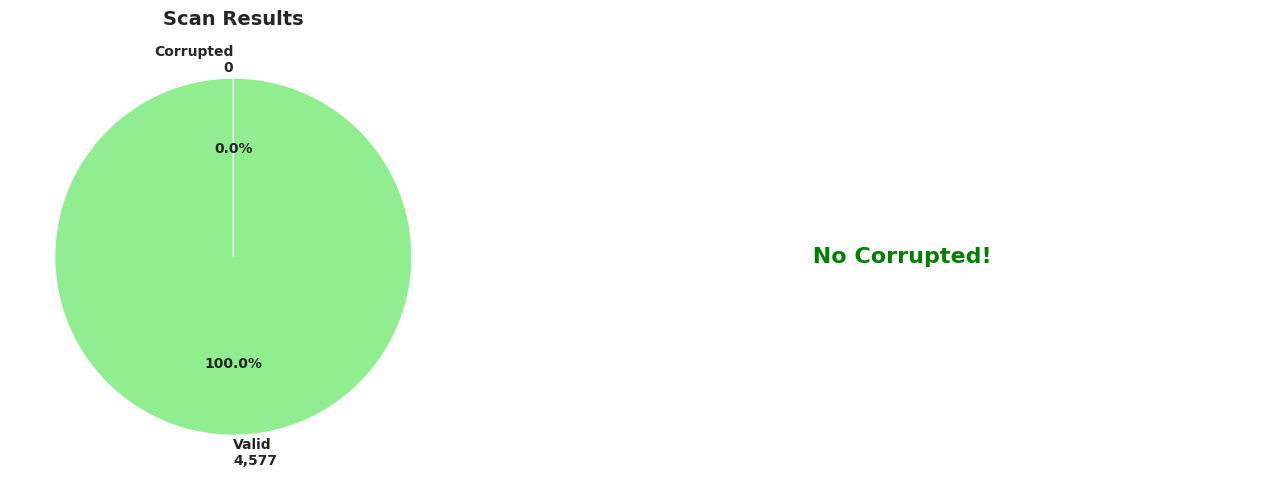

 Saved: 02_scan.png


In [ ]:
print("\n SCANNING FOR CORRUPTED IMAGES...")

def check_img(path):
    try:
        size = os.path.getsize(path)
        if size == 0: return True, "Empty"
        if size < 100: return True, "Too small"
        with Image.open(path) as im: im.verify()
        with Image.open(path) as im: im.load(); im.convert('RGB')
        return False, ""
    except Exception as e:
        return True, str(e)[:30]

corrupted, valid, total = [], [], 0

for cls in tqdm(classes, desc="Scanning"):
    cls_path = os.path.join(DATA_DIR, cls)
    for img in os.listdir(cls_path):
        if img.lower().endswith(('.png','.jpg','.jpeg','.bmp')):
            img_path = os.path.join(cls_path, img)
            total += 1
            bad, err = check_img(img_path)
            if bad:
                corrupted.append({'class': cls, 'file': img, 'error': err})
            else:
                valid.append({'class': cls, 'file': img, 'path': img_path})

print(f"\n SCAN RESULTS:")
print(f"Total: {total:,}")
print(f"Valid: {len(valid):,} ({len(valid)/total*100:.1f}%)")
print(f"Corrupted: {len(corrupted):,} ({len(corrupted)/total*100:.1f}%)")

#  VIZ 2: Scan results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sizes = [len(valid), len(corrupted)]
labels = [f'Valid\n{len(valid):,}', f'Corrupted\n{len(corrupted):,}']
colors = ['#90EE90', '#FFB6C1']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, textprops={'fontweight':'bold'})
axes[0].set_title('Scan Results', fontweight='bold', fontsize=14)

if corrupted:
    by_cls = defaultdict(int)
    for c in corrupted: by_cls[c['class']] += 1
    top_bad = sorted(by_cls.items(), key=lambda x: x[1], reverse=True)[:15]
    if top_bad:
        cls_bad, cnt_bad = zip(*top_bad)
        axes[1].barh(range(len(cls_bad)), cnt_bad, color='salmon', alpha=0.7)
        axes[1].set_yticks(range(len(cls_bad)))
        axes[1].set_yticklabels(cls_bad, fontsize=8)
        axes[1].set_xlabel('Corrupted Count', fontweight='bold')
        axes[1].set_title('Classes with Most Corrupted', fontweight='bold', fontsize=14)
        axes[1].grid(alpha=0.3, axis='x')
else:
    axes[1].text(0.5, 0.5, ' No Corrupted!', ha='center', va='center', fontsize=16, color='green', fontweight='bold')
    axes[1].axis('off')

plt.tight_layout()
plt.savefig(f'{cfg.PLOT_DIR}/02_scan.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: 02_scan.png")

In [ ]:
print("\n COPYING VALID IMAGES...")

for cls in set(v['class'] for v in valid):
    os.makedirs(os.path.join(cfg.CLEANED_DIR, cls), exist_ok=True)

copied = 0
for v in tqdm(valid, desc="Copying"):
    try:
        dst = os.path.join(cfg.CLEANED_DIR, v['class'], v['file'])
        shutil.copy2(v['path'], dst)
        copied += 1
    except: pass

print(f"Copied {copied:,} valid images to {cfg.CLEANED_DIR}")



 COPYING VALID IMAGES...


Copying: 100%|██████████| 4577/4577 [00:04<00:00, 1104.93it/s]

Copied 4,577 valid images to /kaggle/working/cleaned_data



  VERIFYING...


Verifying: 100%|██████████| 100/100 [00:00<00:00, 339.46it/s]


 Verified: 0/4,577 (0.0%)


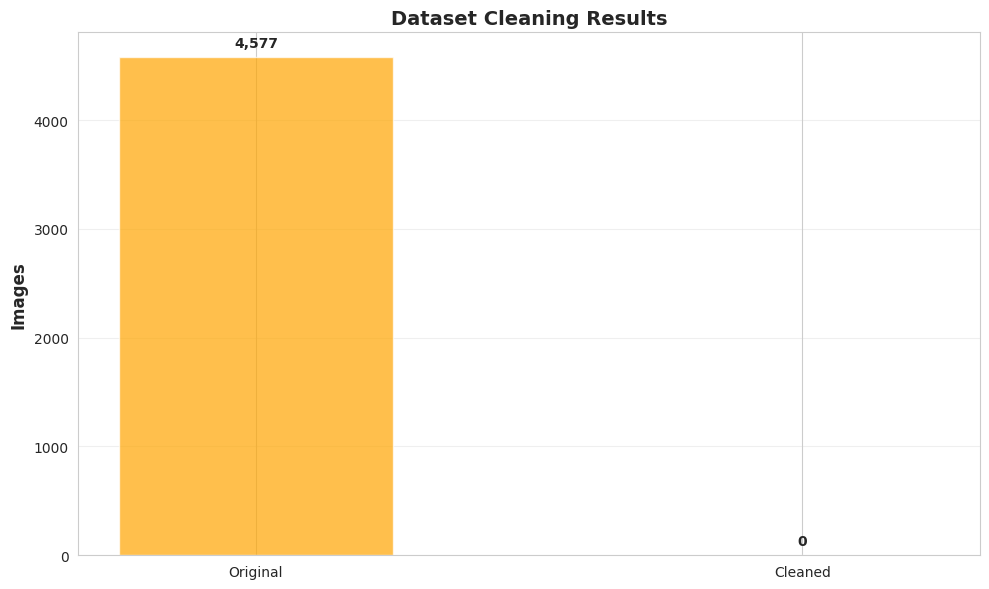

 Saved: 03_comparison.png


In [ ]:
print("\n  VERIFYING...")

verified = 0
for cls in tqdm(os.listdir(cfg.CLEANED_DIR), desc="Verifying"):
    cls_path = os.path.join(cfg.CLEANED_DIR, cls)
    if os.path.isdir(cls_path):
        for img in os.listdir(cls_path):
            try:
                with Image.open(os.path.join(cls_path, img)) as im: im.verify(); im.load()
                verified += 1
            except: pass

print(f" Verified: {verified:,}/{copied:,} ({verified/copied*100:.1f}%)")

#  VIZ 3: Before/After
fig, ax = plt.subplots(figsize=(10, 6))
labels = ['Original', 'Cleaned']
values = [total, verified]
colors = ['orange', 'green']
bars = ax.bar(labels, values, color=colors, alpha=0.7, width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + total*0.02, f'{val:,}', ha='center', fontweight='bold')
ax.set_ylabel('Images', fontweight='bold', fontsize=12)
ax.set_title('Dataset Cleaning Results', fontweight='bold', fontsize=14)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{cfg.PLOT_DIR}/03_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: 03_comparison.png")

In [ ]:
print("\n LOADING CLEANED DATASET FOR TRAINING...")

paths, labels, class_names = [], [], []
classes = sorted(os.listdir(cfg.CLEANED_DIR))

for idx, cls in enumerate(tqdm(classes, desc="Loading")):
    class_names.append(cls)
    cls_path = os.path.join(cfg.CLEANED_DIR, cls)
    for img in os.listdir(cls_path):
        if img.lower().endswith(('.png','.jpg','.jpeg','.bmp')):
            paths.append(os.path.join(cls_path, img))
            labels.append(idx)

cfg.NUM_CLASSES = len(class_names)
print(f"\n Loaded: {len(paths):,} images from {cfg.NUM_CLASSES} classes")


 LOADING CLEANED DATASET FOR TRAINING...


Loading: 100%|██████████| 100/100 [00:00<00:00, 11248.40it/s]


 Loaded: 4,577 images from 100 classes



 SPLITTING DATA...
Train: 3,203 (70.0%)
Val:   687 (15.0%)
Test:  687 (15.0%)


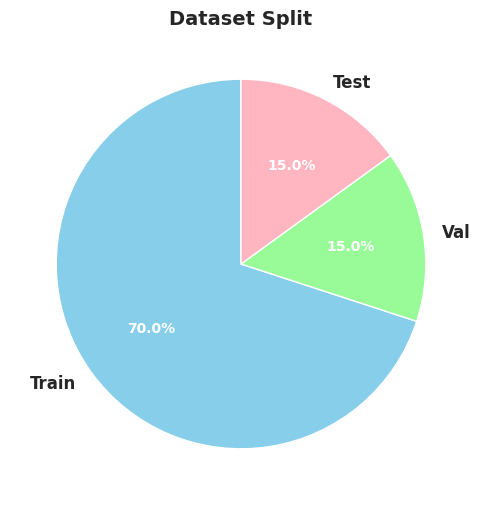

 Saved: 04_split.png


In [ ]:
print("\n SPLITTING DATA...")

X_tr, X_tmp, y_tr, y_tmp = train_test_split(paths, labels, test_size=0.3, random_state=42, stratify=labels)
X_val, X_tst, y_val, y_tst = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp)

print(f"Train: {len(X_tr):,} ({len(X_tr)/len(paths)*100:.1f}%)")
print(f"Val:   {len(X_val):,} ({len(X_val)/len(paths)*100:.1f}%)")
print(f"Test:  {len(X_tst):,} ({len(X_tst)/len(paths)*100:.1f}%)")

#  VIZ 4: Split
fig, ax = plt.subplots(figsize=(8, 6))
split_labels = ['Train', 'Val', 'Test']
split_sizes = [len(X_tr), len(X_val), len(X_tst)]
split_colors = ['#87CEEB', '#98FB98', '#FFB6C1']
wedges, texts, autotexts = ax.pie(split_sizes, labels=split_labels, colors=split_colors, autopct='%1.1f%%', startangle=90, textprops={'fontweight':'bold'})
for text in texts: text.set_fontsize(12)
for autotext in autotexts: autotext.set_color('white'); autotext.set_fontweight('bold')
ax.set_title('Dataset Split', fontweight='bold', fontsize=14)
plt.savefig(f'{cfg.PLOT_DIR}/04_split.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: 04_split.png")

 Transforms defined


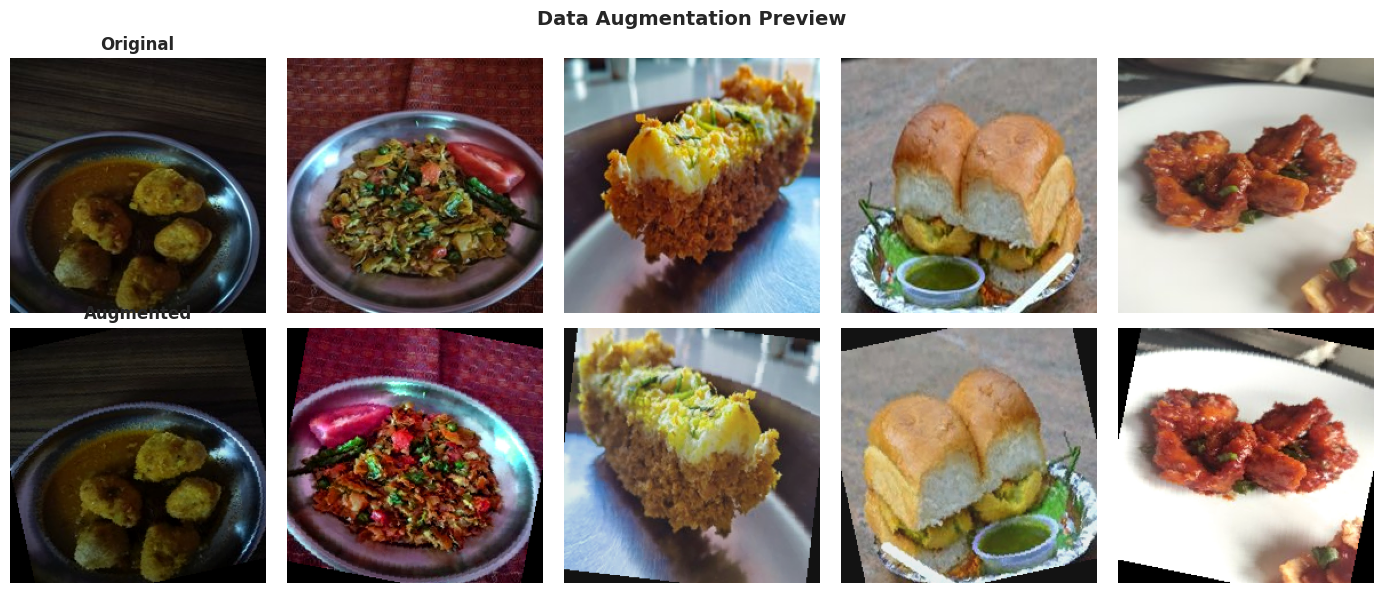

 Saved: 05_augmentation.png


In [ ]:
tr_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print(" Transforms defined")

#  VIZ 5: Augmentation
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
viz_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1)
])
for i in range(5):
    img = Image.open(paths[np.random.randint(len(paths))]).convert('RGB')
    axes[0,i].imshow(img.resize((224,224)))
    axes[0,i].axis('off')
    if i==0: axes[0,i].set_title('Original', fontweight='bold')
    axes[1,i].imshow(viz_tfm(img))
    axes[1,i].axis('off')
    if i==0: axes[1,i].set_title('Augmented', fontweight='bold')
plt.suptitle('Data Augmentation Preview', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(f'{cfg.PLOT_DIR}/05_augmentation.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: 05_augmentation.png")

In [ ]:
class FoodDS(Dataset):
    def __init__(self, paths, labels, tfm=None):
        self.paths, self.labels, self.tfm = paths, labels, tfm
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert('RGB')
        return self.tfm(img) if self.tfm else img, self.labels[i]

tr_ld = DataLoader(FoodDS(X_tr, y_tr, tr_tfm), batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_ld = DataLoader(FoodDS(X_val, y_val, val_tfm), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
tst_ld = DataLoader(FoodDS(X_tst, y_tst, val_tfm), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f" DataLoaders: {len(tr_ld)} train, {len(val_ld)} val, {len(tst_ld)} test batches")

 DataLoaders: 101 train, 22 val, 22 test batches


In [ ]:
class PE(nn.Module):
    def __init__(self, c, d): super().__init__(); self.p = nn.Conv2d(c, d, 1, 1)
    def forward(self, x): return self.p(x).flatten(2).transpose(1, 2)

class TB(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.a = nn.MultiheadAttention(d, h, 0.1)
        self.n1, self.n2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.m = nn.Sequential(nn.Linear(d, d*4), nn.GELU(), nn.Dropout(0.1), nn.Linear(d*4, d), nn.Dropout(0.1))
    def forward(self, x):
        xn = self.n1(x).transpose(0, 1)
        a, _ = self.a(xn, xn, xn)
        x = x + a.transpose(0, 1)
        return x + self.m(self.n2(x))

class Model(nn.Module):
    def __init__(self, n_cls):
        super().__init__()
        bb = models.resnet50(pretrained=True)
        self.cnn = nn.Sequential(*list(bb.children())[:-2])
        self.pe = PE(2048, 768)
        with torch.no_grad():
            o = self.cnn(torch.randn(1, 3, 224, 224))
            np = o.shape[2] * o.shape[3]
        self.cls_t = nn.Parameter(torch.randn(1, 1, 768))
        self.pos = nn.Parameter(torch.randn(1, np+1, 768))
        self.d = nn.Dropout(0.1)
        self.t = nn.ModuleList([TB(768, 12) for _ in range(6)])
        self.n = nn.LayerNorm(768)
        self.h = nn.Sequential(nn.Linear(768, 384), nn.GELU(), nn.Dropout(0.1), nn.Linear(384, n_cls))
    def forward(self, x):
        B = x.shape[0]
        x = self.cnn(x)
        x = self.pe(x)
        c = self.cls_t.expand(B, -1, -1)
        x = torch.cat([c, x], 1) + self.pos
        x = self.d(x)
        for t in self.t: x = t(x)
        return self.h(self.n(x[:, 0]))

model = Model(cfg.NUM_CLASSES).to(cfg.DEVICE)
print(f" Model built: {sum(p.numel() for p in model.parameters()):,} params")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 218MB/s]


 Model built: 67,983,396 params


In [ ]:
def train_ep(m, ld, crit, opt, dev):
    m.train()
    ls, cor, tot = 0, 0, 0
    for im, lb in tqdm(ld, desc='Train', leave=False):
        im, lb = im.to(dev), lb.to(dev)
        opt.zero_grad()
        o = m(im)
        l = crit(o, lb)
        l.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step()
        ls += l.item()
        _, p = torch.max(o, 1)
        tot += lb.size(0)
        cor += (p == lb).sum().item()
    return ls/len(ld), 100.*cor/tot

def val(m, ld, crit, dev):
    m.eval()
    ls, cor, tot = 0, 0, 0
    with torch.no_grad():
        for im, lb in tqdm(ld, desc='Val', leave=False):
            im, lb = im.to(dev), lb.to(dev)
            o = m(im)
            ls += crit(o, lb).item()
            _, p = torch.max(o, 1)
            tot += lb.size(0)
            cor += (p == lb).sum().item()
    return ls/len(ld), 100.*cor/tot

print(" Training functions ready")

 Training functions ready



 TRAINING...

Epoch 1/50


Train: Loss=3.9705, Acc=14.33%
Val:   Loss=2.5787, Acc=47.89%
 Saved! Best: 47.89%

Epoch 2/50


Train: Loss=1.8891, Acc=60.51%
Val:   Loss=1.2290, Acc=73.94%
 Saved! Best: 73.94%

Epoch 3/50


Train: Loss=0.9709, Acc=79.30%
Val:   Loss=0.8346, Acc=82.39%
 Saved! Best: 82.39%

Epoch 4/50


Train: Loss=0.5712, Acc=86.86%
Val:   Loss=0.6908, Acc=84.28%
 Saved! Best: 84.28%

Epoch 5/50


Train: Loss=0.3518, Acc=92.29%
Val:   Loss=0.5536, Acc=87.63%
 Saved! Best: 87.63%


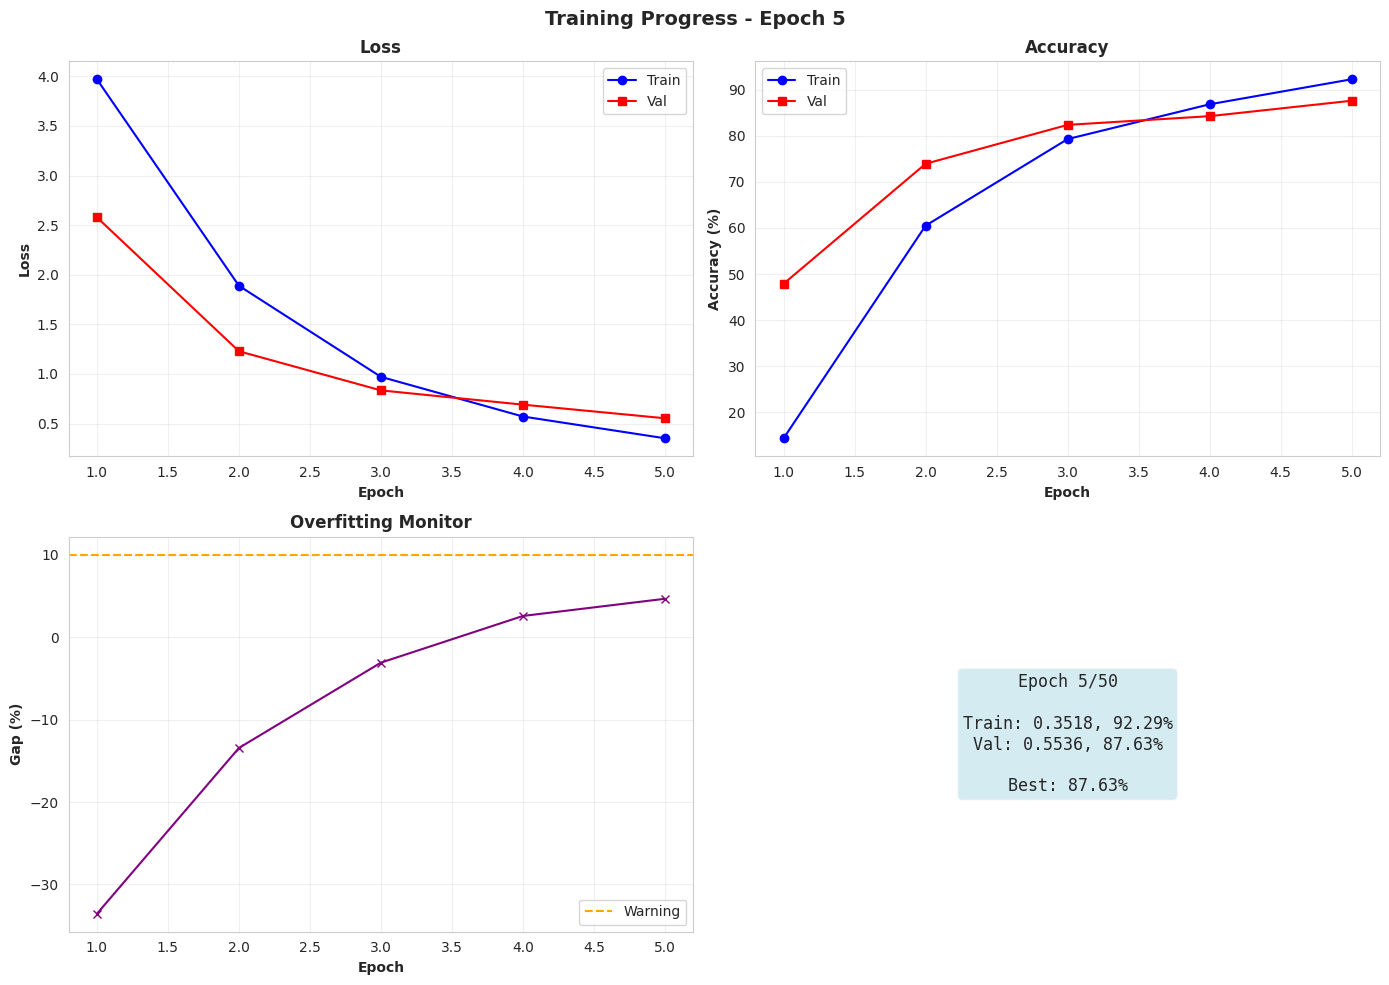


Epoch 6/50


Train: Loss=0.2144, Acc=95.38%
Val:   Loss=0.4990, Acc=88.36%
 Saved! Best: 88.36%

Epoch 7/50


Train: Loss=0.1234, Acc=97.66%
Val:   Loss=0.5053, Acc=88.94%
 Saved! Best: 88.94%

Epoch 8/50


Train: Loss=0.0796, Acc=98.91%
Val:   Loss=0.4824, Acc=89.37%
 Saved! Best: 89.37%

Epoch 9/50


Train: Loss=0.0561, Acc=99.25%
Val:   Loss=0.4742, Acc=89.81%
 Saved! Best: 89.81%

Epoch 10/50


Train: Loss=0.0363, Acc=99.47%
Val:   Loss=0.4685, Acc=90.25%
 Saved! Best: 90.25%


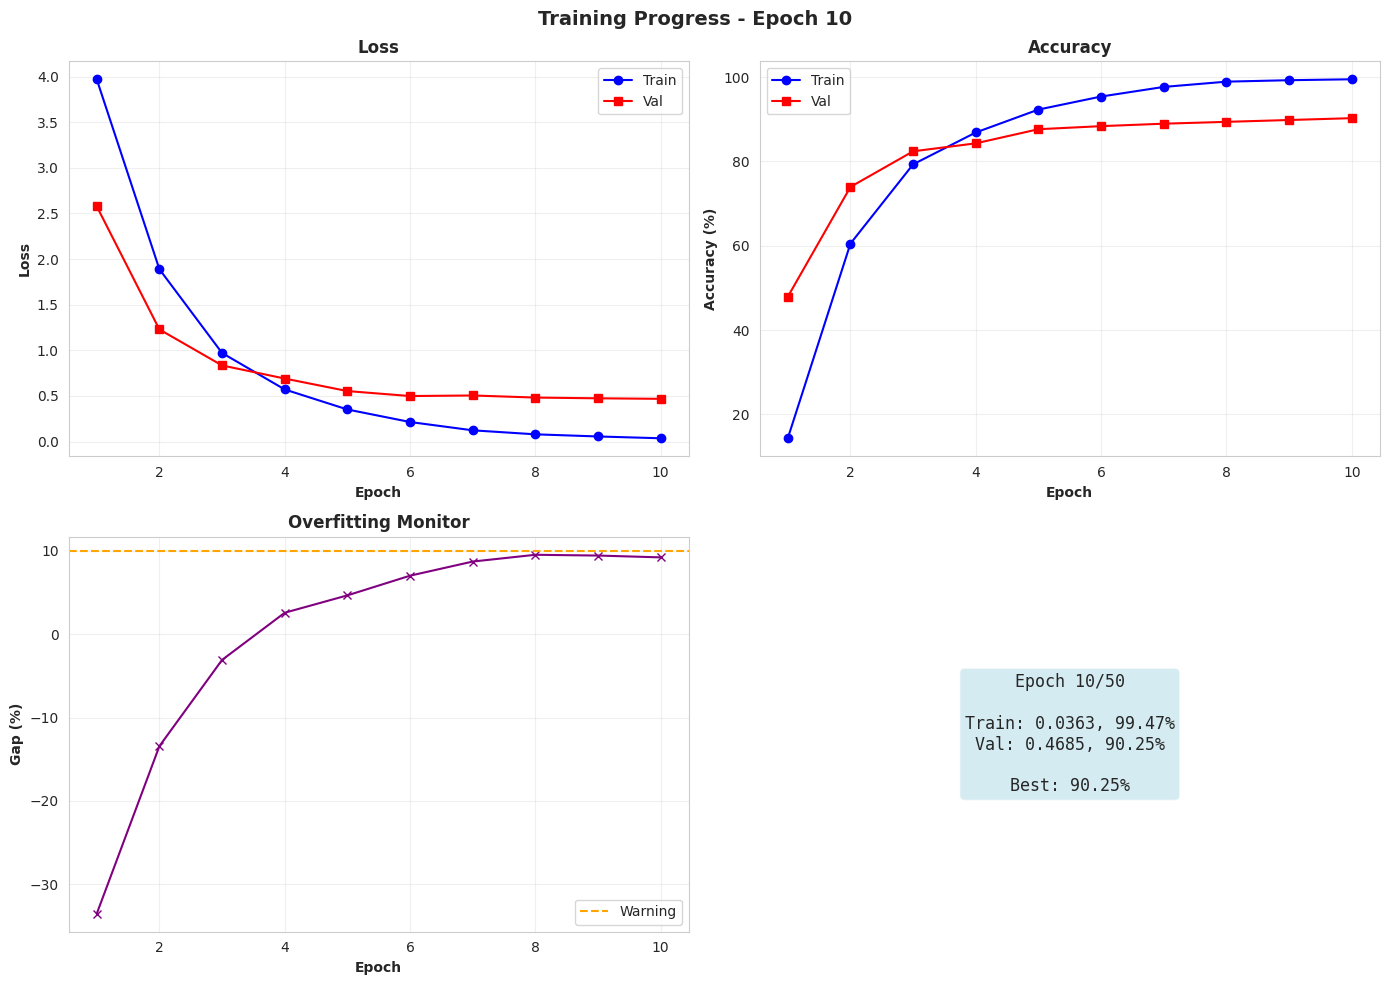


Epoch 11/50


Train: Loss=0.1698, Acc=96.03%
Val:   Loss=0.6833, Acc=84.57%

Epoch 12/50


Train: Loss=0.2396, Acc=94.82%
Val:   Loss=0.7064, Acc=85.74%

Epoch 13/50


Train: Loss=0.1981, Acc=95.29%
Val:   Loss=0.7403, Acc=85.74%

Epoch 14/50


Train: Loss=0.1334, Acc=96.88%
Val:   Loss=0.6951, Acc=86.90%

Epoch 15/50


Train: Loss=0.1023, Acc=97.66%
Val:   Loss=0.7015, Acc=86.03%


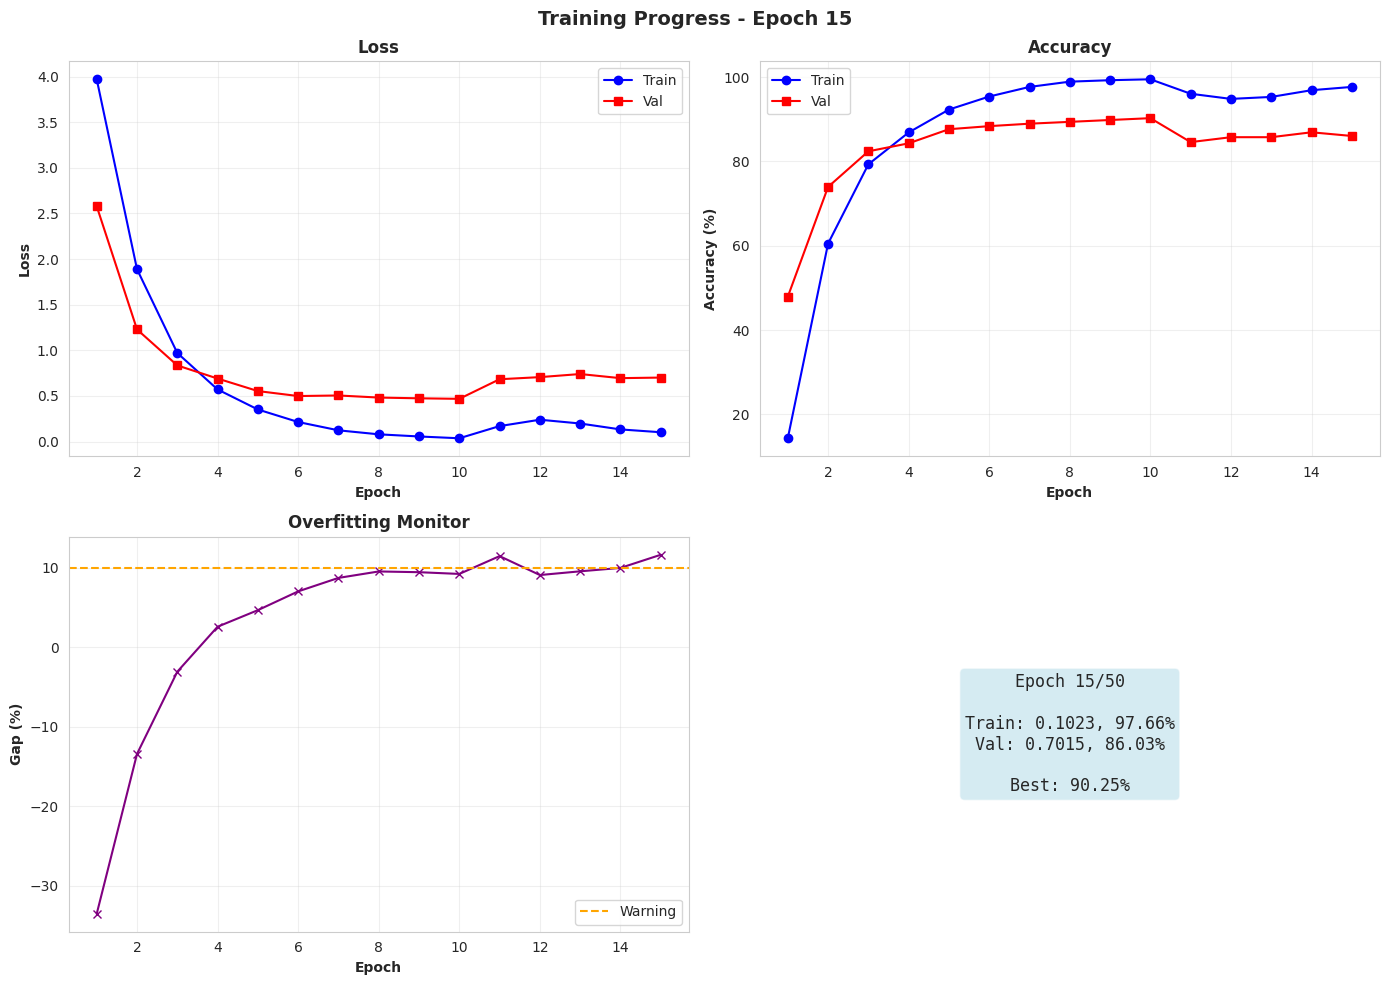


Epoch 16/50


Train: Loss=0.0545, Acc=98.53%
Val:   Loss=0.6660, Acc=87.05%

Epoch 17/50


Train: Loss=0.0400, Acc=99.06%
Val:   Loss=0.5654, Acc=89.67%

Epoch 18/50


Train: Loss=0.0414, Acc=99.50%
Val:   Loss=0.5859, Acc=89.08%

Epoch 19/50


Train: Loss=0.0157, Acc=99.59%
Val:   Loss=0.5936, Acc=89.52%

Epoch 20/50


Train: Loss=0.0093, Acc=99.72%
Val:   Loss=0.5906, Acc=89.23%


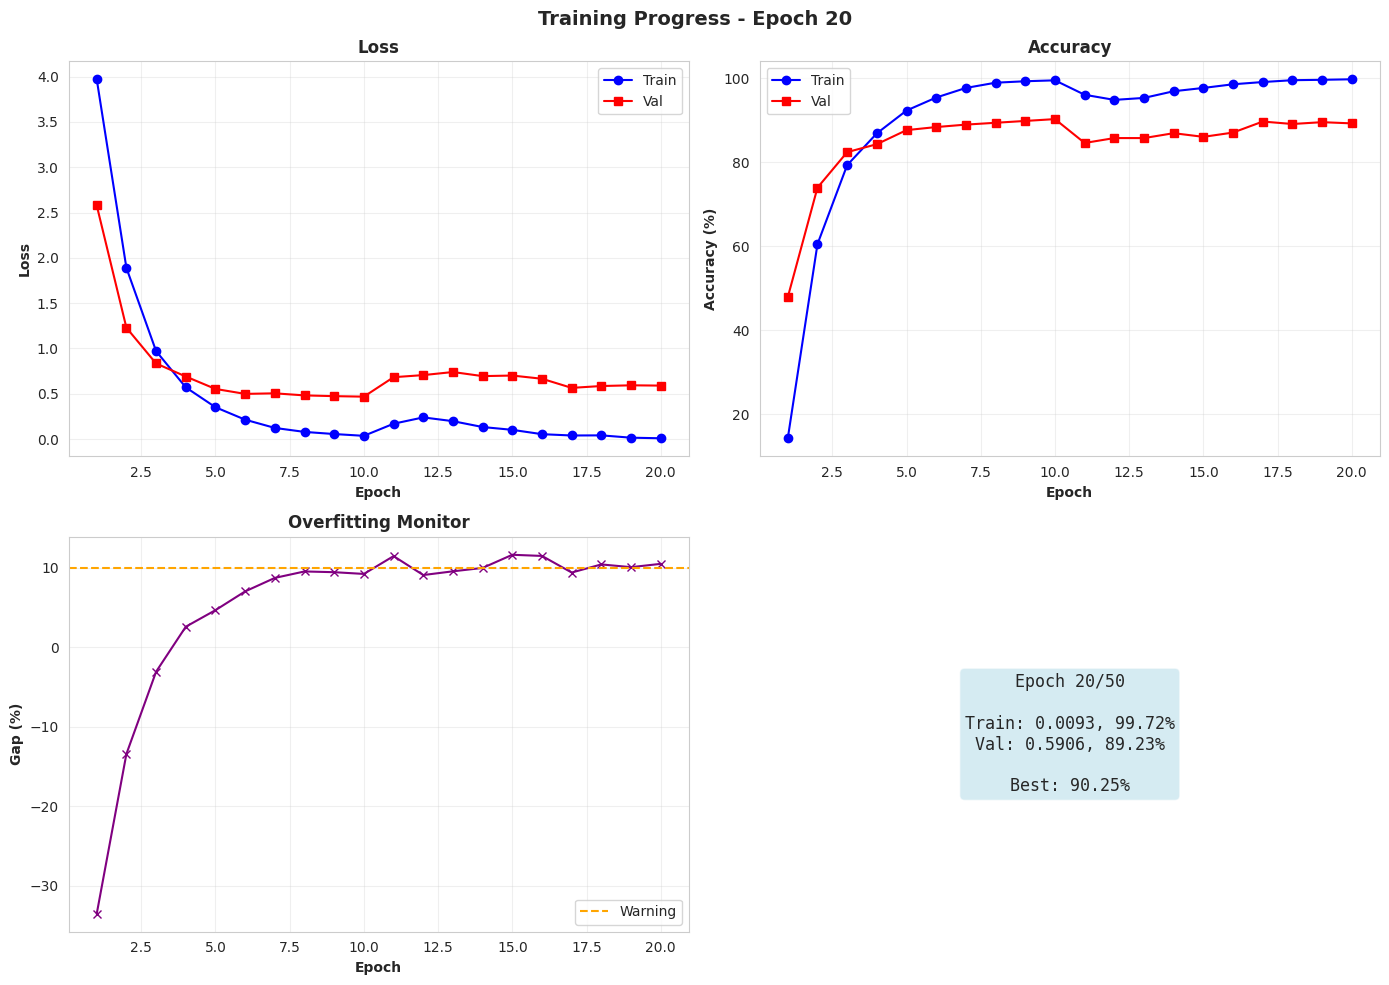


Epoch 21/50


Train: Loss=0.0800, Acc=98.50%
Val:   Loss=0.7450, Acc=85.01%

Epoch 22/50


Train: Loss=0.1624, Acc=95.85%
Val:   Loss=0.9335, Acc=83.84%

Epoch 23/50


Train: Loss=0.1900, Acc=96.32%
Val:   Loss=0.8744, Acc=84.28%

Epoch 24/50


Train: Loss=0.0993, Acc=97.41%
Val:   Loss=0.8474, Acc=84.86%

Epoch 25/50


Train: Loss=0.0904, Acc=97.97%
Val:   Loss=0.8080, Acc=87.48%


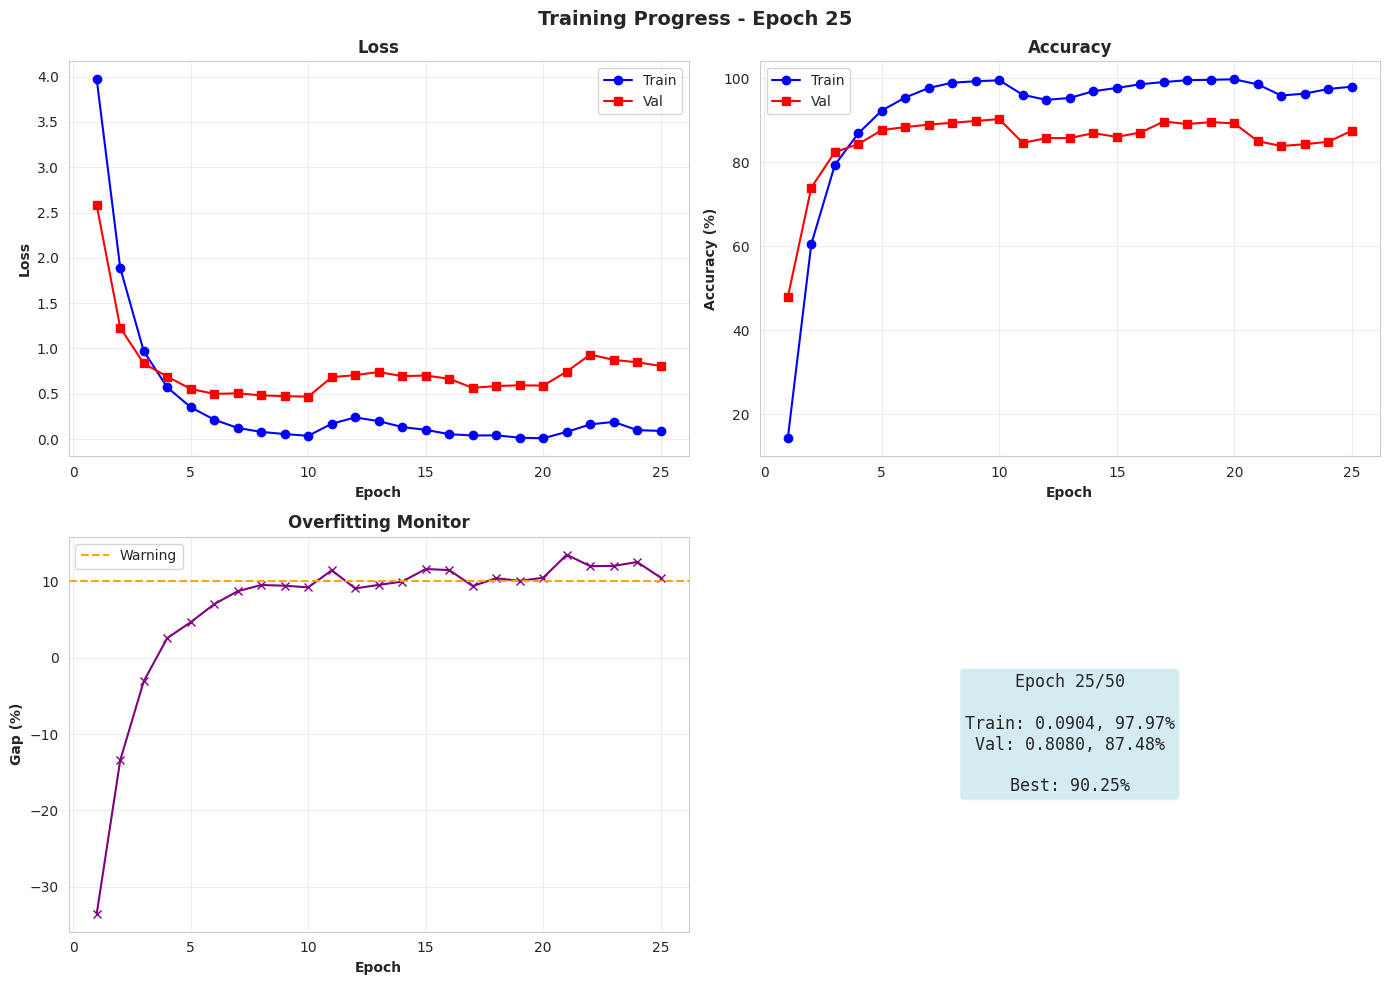


Epoch 26/50


Train: Loss=0.0524, Acc=98.88%
Val:   Loss=0.7839, Acc=88.79%

Epoch 27/50


Train: Loss=0.0205, Acc=99.47%
Val:   Loss=0.7166, Acc=88.79%

Epoch 28/50


Train: Loss=0.0250, Acc=99.47%
Val:   Loss=0.6972, Acc=88.79%

Epoch 29/50


Train: Loss=0.0080, Acc=99.72%
Val:   Loss=0.7100, Acc=88.79%

Epoch 30/50


Train: Loss=0.0090, Acc=99.78%
Val:   Loss=0.7156, Acc=89.37%


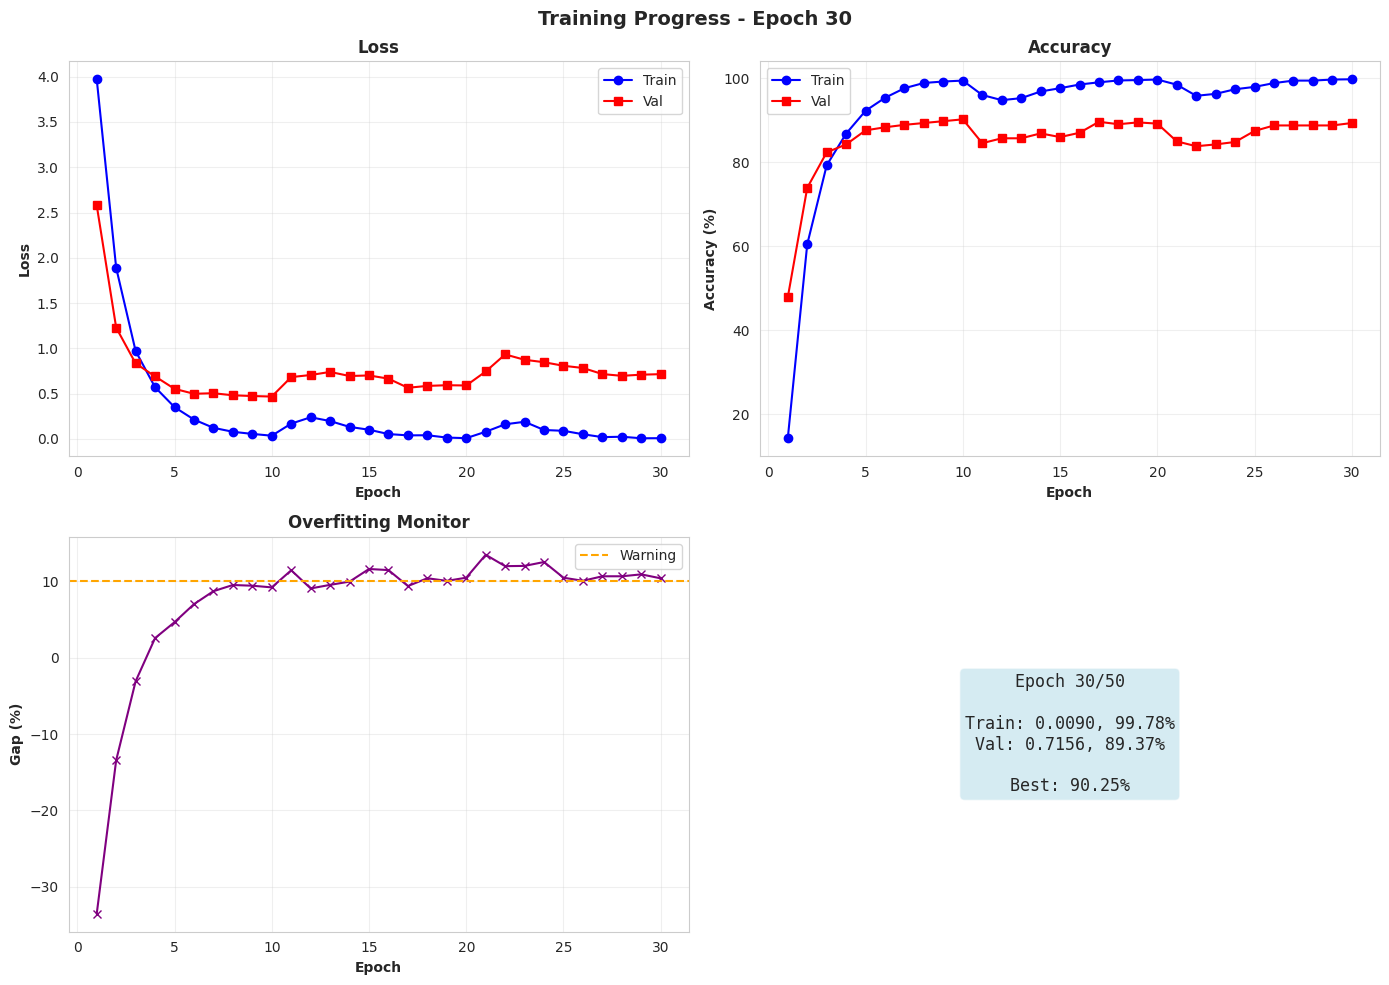


Epoch 31/50


Train: Loss=0.1143, Acc=97.97%
Val:   Loss=0.9038, Acc=86.03%

Epoch 32/50


Train: Loss=0.1833, Acc=95.97%
Val:   Loss=0.9050, Acc=83.70%

Epoch 33/50


Train: Loss=0.1243, Acc=96.78%
Val:   Loss=0.9107, Acc=84.43%

Epoch 34/50


Train: Loss=0.0793, Acc=97.69%
Val:   Loss=0.9084, Acc=85.88%

Epoch 35/50


Train: Loss=0.0704, Acc=98.31%
Val:   Loss=0.8452, Acc=86.17%


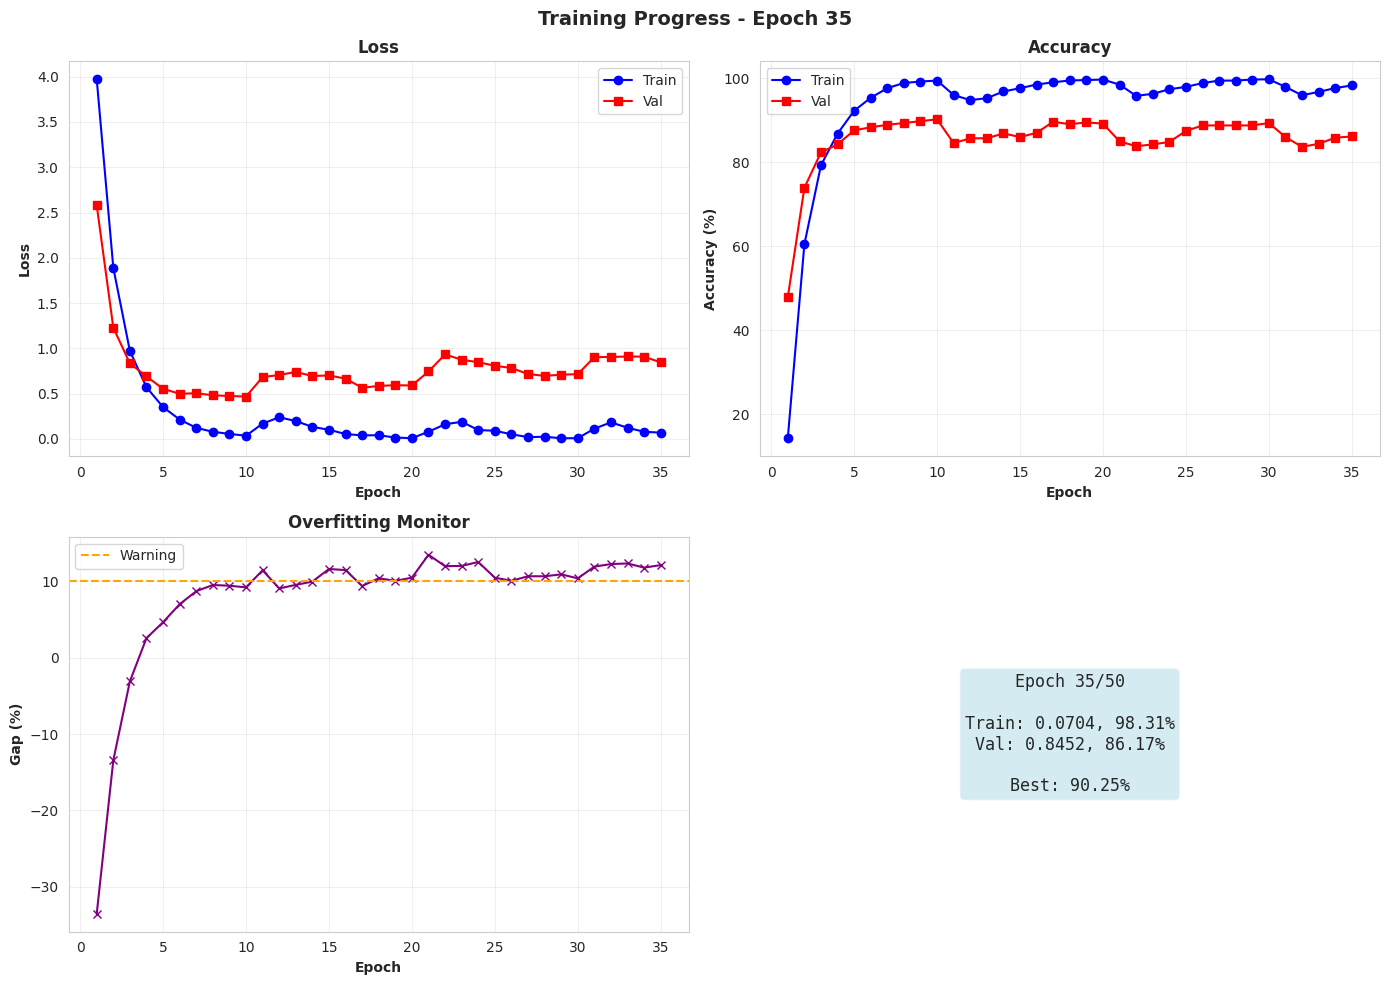


Epoch 36/50


Train: Loss=0.0326, Acc=99.16%
Val:   Loss=0.7638, Acc=88.36%

Epoch 37/50


Train: Loss=0.0317, Acc=99.31%
Val:   Loss=0.6639, Acc=89.96%

Epoch 38/50


Train: Loss=0.0134, Acc=99.53%
Val:   Loss=0.6793, Acc=89.37%

Epoch 39/50


Train: Loss=0.0057, Acc=99.75%
Val:   Loss=0.6745, Acc=89.96%

Epoch 40/50


Train: Loss=0.0071, Acc=99.66%
Val:   Loss=0.7072, Acc=89.52%


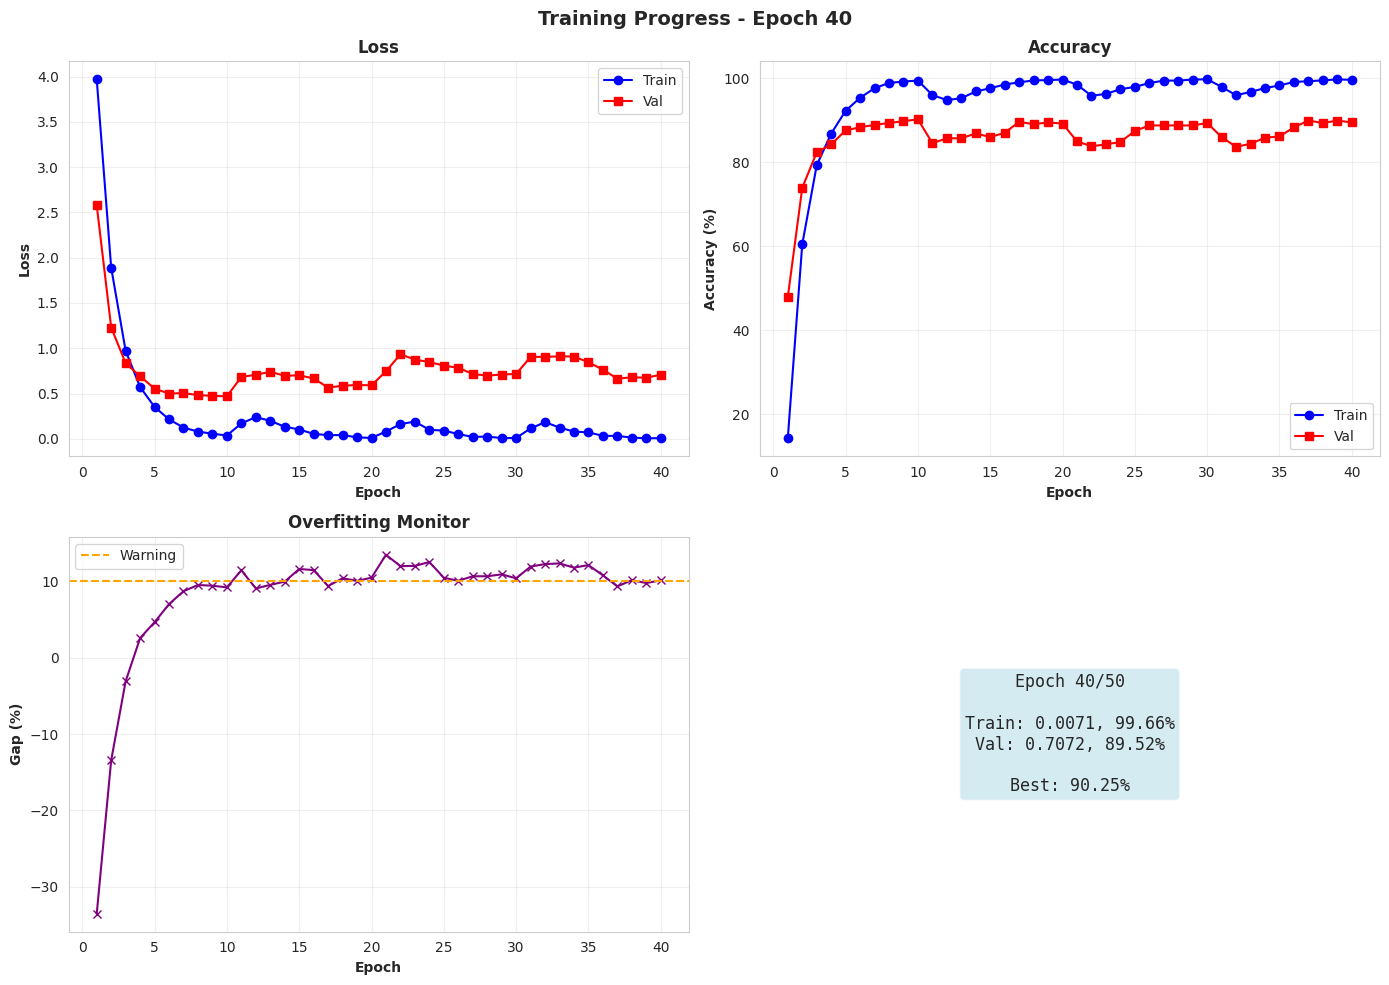


Epoch 41/50


Train: Loss=0.0512, Acc=98.63%
Val:   Loss=0.7855, Acc=87.34%

Epoch 42/50


Train: Loss=0.1648, Acc=97.10%
Val:   Loss=0.9635, Acc=84.57%

Epoch 43/50


Train: Loss=0.1435, Acc=96.10%
Val:   Loss=0.9292, Acc=85.01%

Epoch 44/50


Train: Loss=0.1138, Acc=97.47%
Val:   Loss=0.8494, Acc=86.17%

Epoch 45/50


Train: Loss=0.0937, Acc=98.44%
Val:   Loss=0.8125, Acc=87.77%


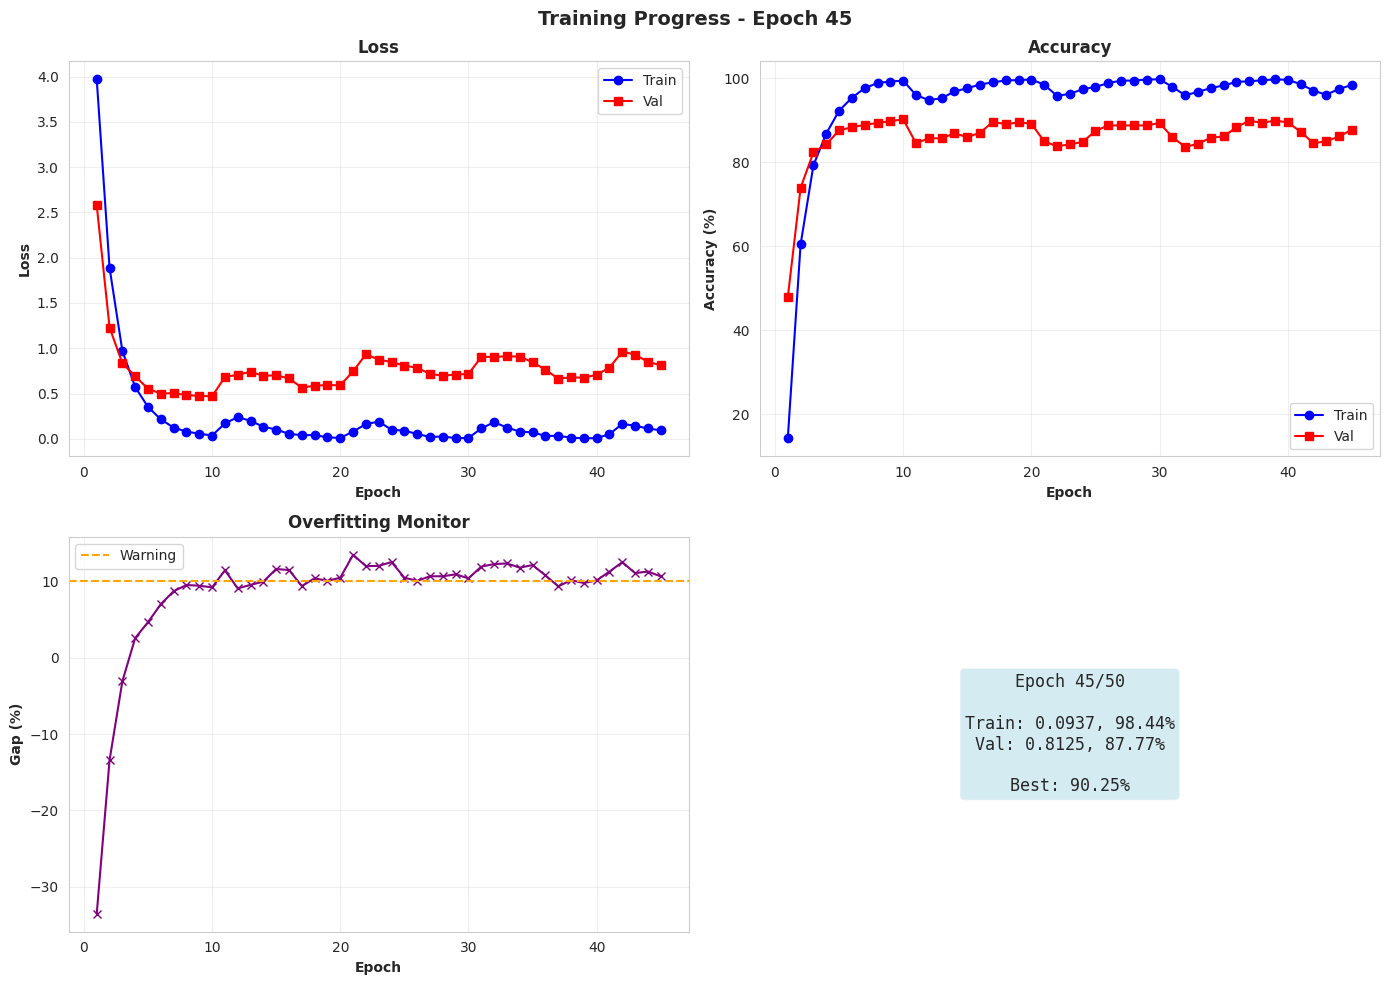


Epoch 46/50


Train: Loss=0.0330, Acc=99.13%
Val:   Loss=0.8844, Acc=87.48%

Epoch 47/50


Train: Loss=0.0256, Acc=99.28%
Val:   Loss=0.7454, Acc=88.50%

Epoch 48/50


Train: Loss=0.0087, Acc=99.59%
Val:   Loss=0.7403, Acc=88.94%

Epoch 49/50


Train: Loss=0.0124, Acc=99.72%
Val:   Loss=0.7407, Acc=88.94%

Epoch 50/50


Train: Loss=0.0074, Acc=99.66%
Val:   Loss=0.7279, Acc=89.37%


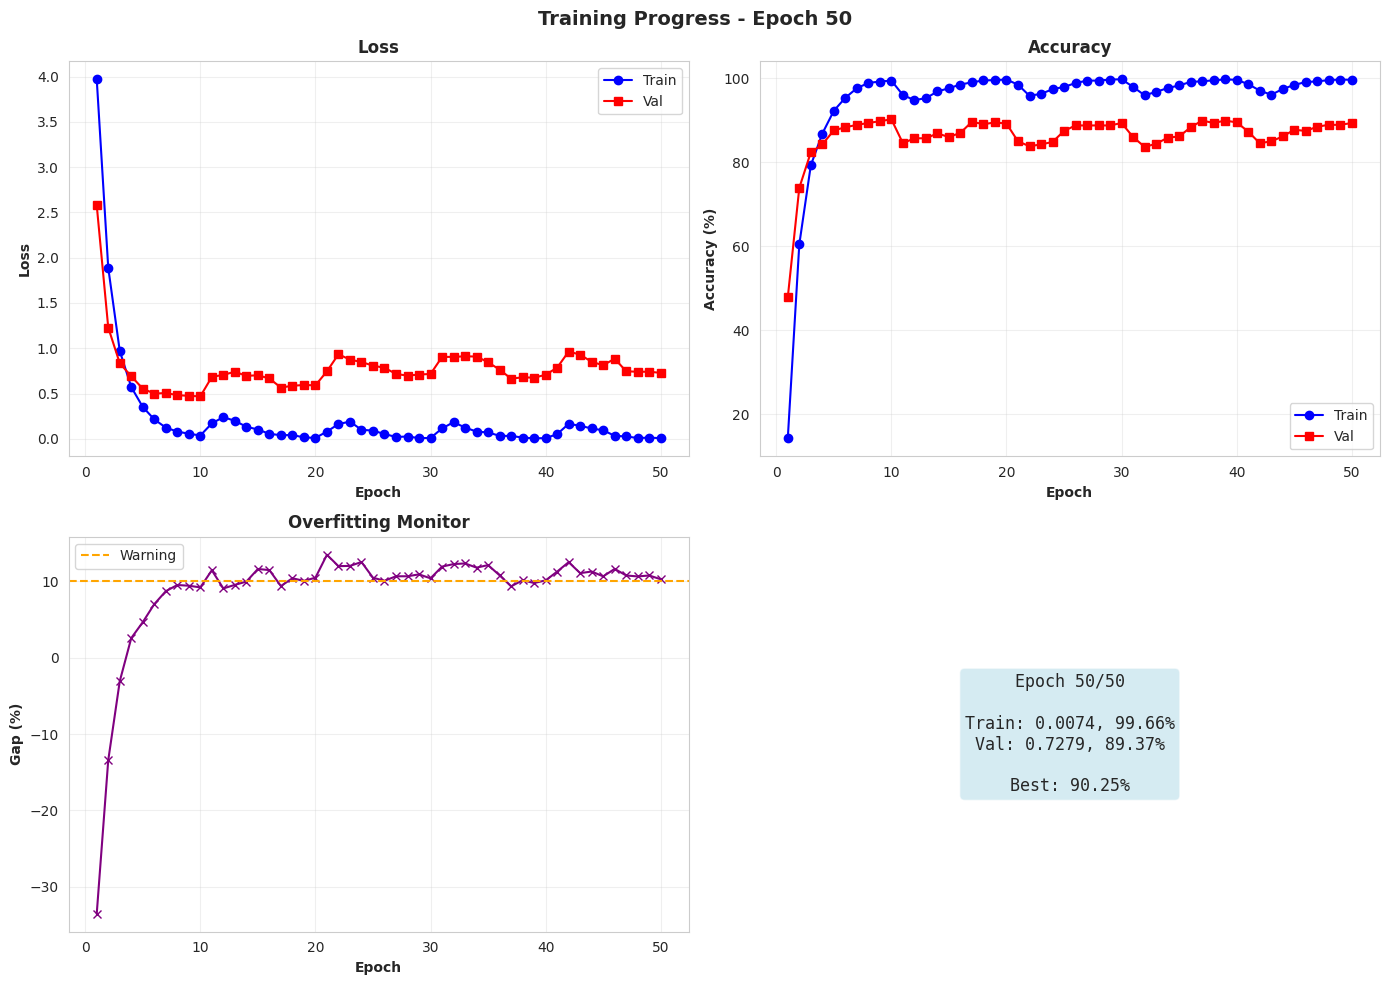


 Training complete! Best: 90.25%


In [ ]:
print("\n TRAINING...")

crit = nn.CrossEntropyLoss()
opt = optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=0.01)
sch = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=10, eta_min=1e-6)

hist = {'trl': [], 'tra': [], 'vl': [], 'va': []}
best = 0

for e in range(1, cfg.EPOCHS + 1):
    print(f"\n{'='*80}\nEpoch {e}/{cfg.EPOCHS}\n{'='*80}")
    trl, tra = train_ep(model, tr_ld, crit, opt, cfg.DEVICE)
    vl, va = val(model, val_ld, crit, cfg.DEVICE)
    sch.step()

    hist['trl'].append(trl)
    hist['tra'].append(tra)
    hist['vl'].append(vl)
    hist['va'].append(va)

    print(f"Train: Loss={trl:.4f}, Acc={tra:.2f}%")
    print(f"Val:   Loss={vl:.4f}, Acc={va:.2f}%")

    if va > best:
        best = va
        torch.save(model.state_dict(), f'{cfg.MODEL_DIR}/best.pth')
        print(f" Saved! Best: {va:.2f}%")

    #  VIZ 6: Training Progress (every 5 epochs)
    if e % 5 == 0 or e == cfg.EPOCHS:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        epochs = range(1, len(hist['trl']) + 1)

        axes[0,0].plot(epochs, hist['trl'], 'b-', label='Train', marker='o')
        axes[0,0].plot(epochs, hist['vl'], 'r-', label='Val', marker='s')
        axes[0,0].set_xlabel('Epoch', fontweight='bold')
        axes[0,0].set_ylabel('Loss', fontweight='bold')
        axes[0,0].set_title('Loss', fontweight='bold', fontsize=12)
        axes[0,0].legend()
        axes[0,0].grid(alpha=0.3)

        axes[0,1].plot(epochs, hist['tra'], 'b-', label='Train', marker='o')
        axes[0,1].plot(epochs, hist['va'], 'r-', label='Val', marker='s')
        axes[0,1].set_xlabel('Epoch', fontweight='bold')
        axes[0,1].set_ylabel('Accuracy (%)', fontweight='bold')
        axes[0,1].set_title('Accuracy', fontweight='bold', fontsize=12)
        axes[0,1].legend()
        axes[0,1].grid(alpha=0.3)

        gap = np.array(hist['tra']) - np.array(hist['va'])
        axes[1,0].plot(epochs, gap, 'purple', marker='x')
        axes[1,0].axhline(10, color='orange', linestyle='--', label='Warning')
        axes[1,0].set_xlabel('Epoch', fontweight='bold')
        axes[1,0].set_ylabel('Gap (%)', fontweight='bold')
        axes[1,0].set_title('Overfitting Monitor', fontweight='bold', fontsize=12)
        axes[1,0].legend()
        axes[1,0].grid(alpha=0.3)

        axes[1,1].axis('off')
        stats = f"Epoch {e}/{cfg.EPOCHS}\n\nTrain: {trl:.4f}, {tra:.2f}%\nVal: {vl:.4f}, {va:.2f}%\n\nBest: {best:.2f}%"
        axes[1,1].text(0.5, 0.5, stats, ha='center', va='center', fontsize=12, family='monospace', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

        plt.suptitle(f'Training Progress - Epoch {e}', fontweight='bold', fontsize=14)
        plt.tight_layout()
        plt.savefig(f'{cfg.PLOT_DIR}/06_progress_e{e:03d}.png', dpi=200, bbox_inches='tight')
        plt.show()

print(f"\n Training complete! Best: {best:.2f}%")


In [ ]:
print("\n EVALUATING...")

model.load_state_dict(torch.load(f'{cfg.MODEL_DIR}/best.pth'))
model.eval()

preds, lbls = [], []
with torch.no_grad():
    for im, lb in tqdm(tst_ld, desc='Testing'):
        o = model(im.to(cfg.DEVICE))
        _, p = torch.max(o, 1)
        preds.extend(p.cpu().numpy())
        lbls.extend(lb.numpy())

acc = accuracy_score(lbls, preds)
print(f"\n Test Accuracy: {acc*100:.2f}%")


 EVALUATING...


Testing: 100%|██████████| 22/22 [00:03<00:00,  5.86it/s]


 Test Accuracy: 89.08%


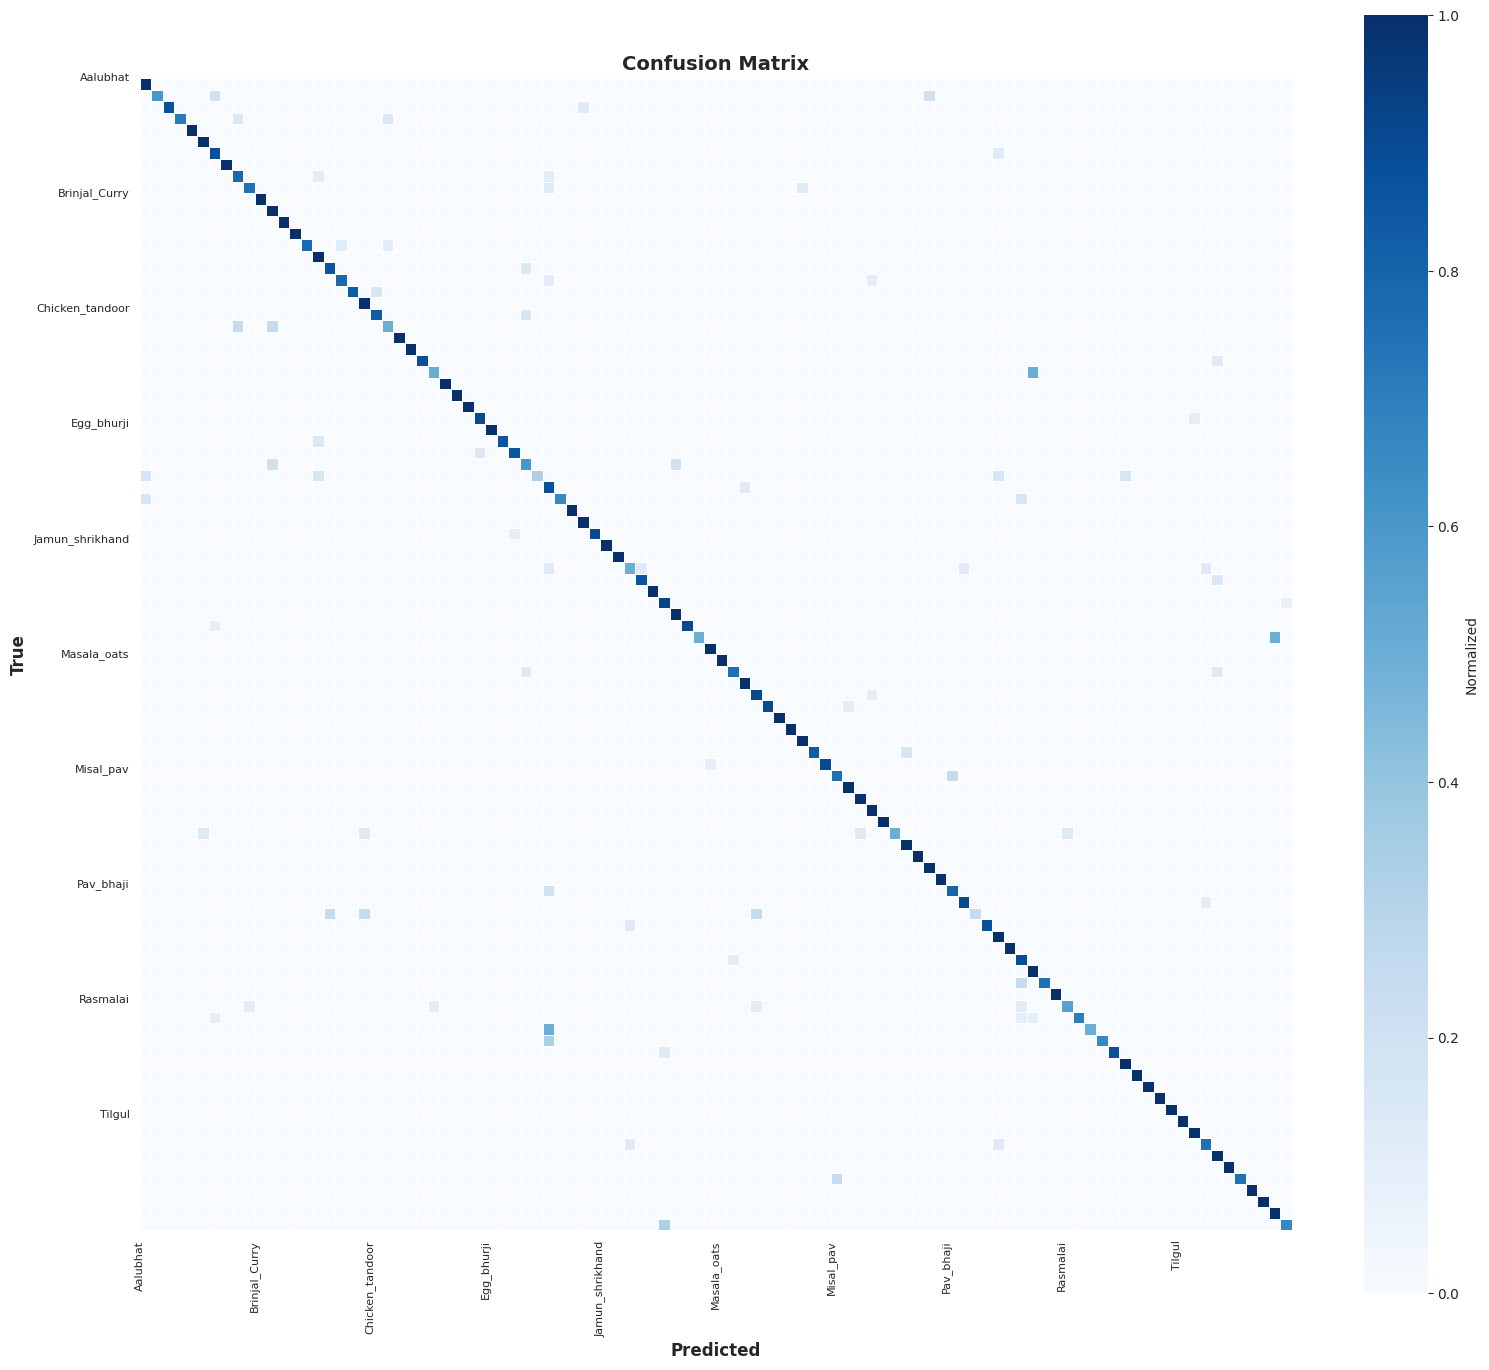

 Saved: 07_confusion.png


In [ ]:
cm = confusion_matrix(lbls, preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(16, 14))
sns.heatmap(cm_norm, annot=False, cmap='Blues', square=True, linewidths=0.5, cbar_kws={'label': 'Normalized'})
plt.xlabel('Predicted', fontweight='bold', fontsize=12)
plt.ylabel('True', fontweight='bold', fontsize=12)
plt.title('Confusion Matrix', fontweight='bold', fontsize=14)
tick_marks = np.arange(0, len(class_names), 10)
plt.xticks(tick_marks, [class_names[i] for i in tick_marks], rotation=90, fontsize=8)
plt.yticks(tick_marks, [class_names[i] for i in tick_marks], rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(f'{cfg.PLOT_DIR}/07_confusion.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: 07_confusion.png")

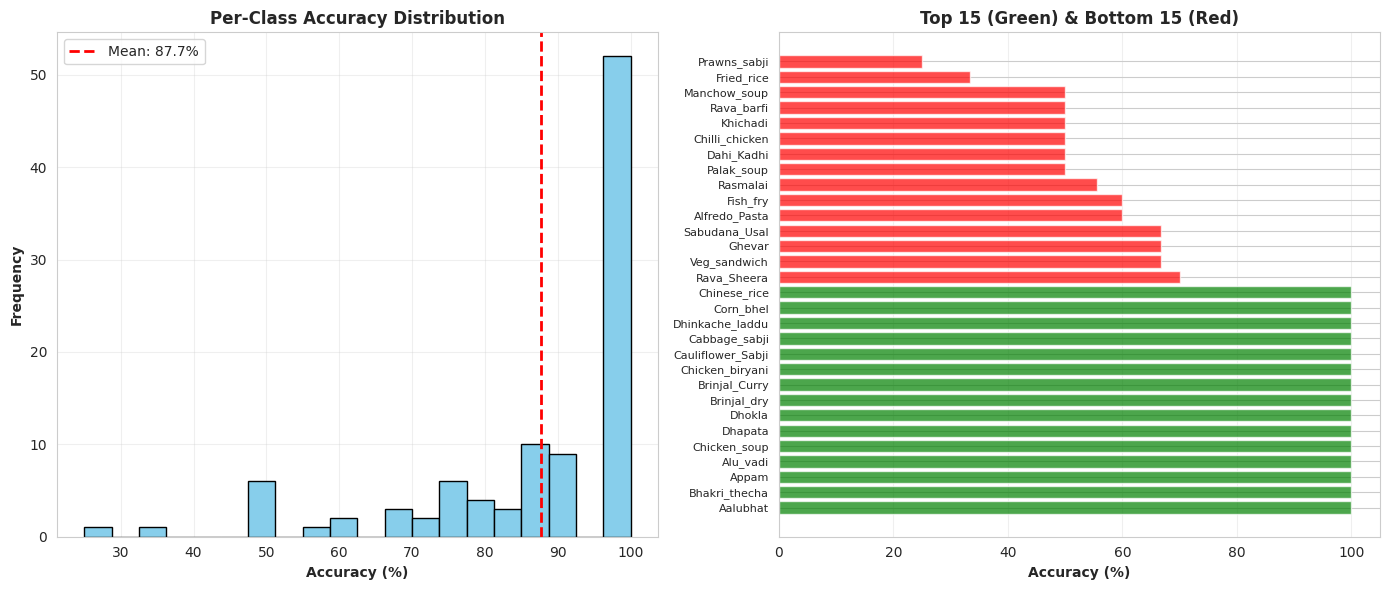

 Saved: 08_per_class.png

Avg: 87.70% | Std: 17.09%

Top 5:
        Class   Acc
     Aalubhat 100.0
Bhakri_thecha 100.0
        Appam 100.0
     Alu_vadi 100.0
 Chicken_soup 100.0

Bottom 5:
       Class       Acc
    Khichadi 50.000000
  Rava_barfi 50.000000
Manchow_soup 50.000000
  Fried_rice 33.333333
Prawns_sabji 25.000000


In [ ]:
per_cls = cm.diagonal() / cm.sum(axis=1) * 100
df_cls = pd.DataFrame({'Class': class_names, 'Acc': per_cls}).sort_values('Acc', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(per_cls, bins=20, color='skyblue', edgecolor='black')
axes[0].axvline(per_cls.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {per_cls.mean():.1f}%')
axes[0].set_xlabel('Accuracy (%)', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Per-Class Accuracy Distribution', fontweight='bold', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

top_bot = pd.concat([df_cls.head(15), df_cls.tail(15)])
colors = ['green']*15 + ['red']*15
axes[1].barh(range(len(top_bot)), top_bot['Acc'], color=colors, alpha=0.7)
axes[1].set_yticks(range(len(top_bot)))
axes[1].set_yticklabels(top_bot['Class'], fontsize=8)
axes[1].set_xlabel('Accuracy (%)', fontweight='bold')
axes[1].set_title('Top 15 (Green) & Bottom 15 (Red)', fontweight='bold', fontsize=12)
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'{cfg.PLOT_DIR}/08_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: 08_per_class.png")
print(f"\nAvg: {per_cls.mean():.2f}% | Std: {per_cls.std():.2f}%")
print(f"\nTop 5:\n{df_cls.head(5).to_string(index=False)}")
print(f"\nBottom 5:\n{df_cls.tail(5).to_string(index=False)}")

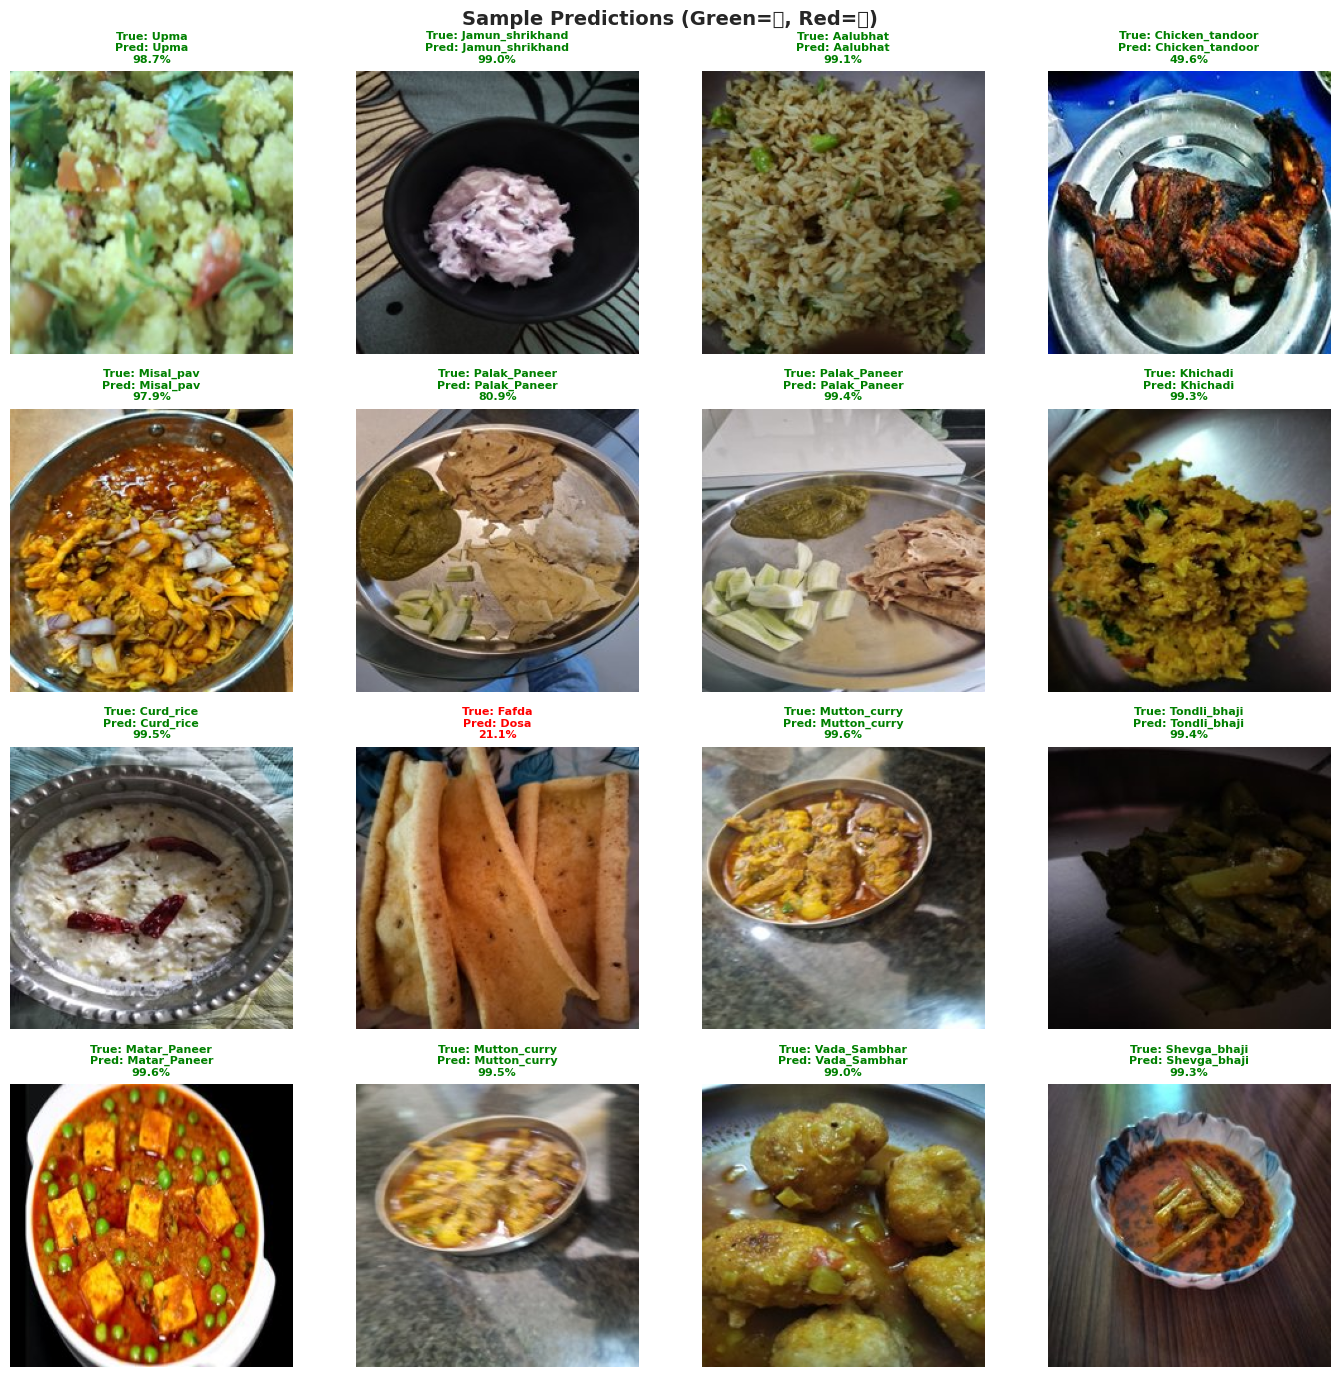

 Saved: 09_predictions.png


In [ ]:
model.eval()
imgs, lbs = next(iter(tst_ld))
imgs_show = imgs[:16]
lbs_show = lbs[:16]

with torch.no_grad():
    outs = model(imgs_show.to(cfg.DEVICE))
    probs = torch.softmax(outs, 1)
    confs, prs = torch.max(probs, 1)

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
imgs_show = imgs_show * std + mean
imgs_show = torch.clamp(imgs_show, 0, 1)

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
axes = axes.ravel()

for i in range(16):
    img = imgs_show[i].permute(1, 2, 0).cpu().numpy()
    true = class_names[lbs_show[i].item()][:20]
    pred = class_names[prs[i].item()][:20]
    conf = confs[i].item() * 100

    axes[i].imshow(img)
    axes[i].axis('off')

    color = 'green' if prs[i] == lbs_show[i] else 'red'
    title = f"True: {true}\nPred: {pred}\n{conf:.1f}%"
    axes[i].set_title(title, fontsize=8, color=color, fontweight='bold')

plt.suptitle('Sample Predictions (Green=✅, Red=❌)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(f'{cfg.PLOT_DIR}/09_predictions.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: 09_predictions.png")

In [ ]:
report = classification_report(lbls, preds, target_names=class_names, digits=3)
print("\n CLASSIFICATION REPORT:")
print(report)

with open(f'{cfg.PLOT_DIR}/report.txt', 'w') as f:
    f.write(report)
print(" Saved: report.txt")


 CLASSIFICATION REPORT:
                          precision    recall  f1-score   support

                Aalubhat      0.778     1.000     0.875         7
           Alfredo_Pasta      1.000     0.600     0.750         5
            Aloo_Paratha      1.000     0.875     0.933         8
              Aloo_sabji      1.000     0.714     0.833         7
                Alu_vadi      1.000     1.000     1.000         6
                   Appam      0.833     1.000     0.909         5
                 Basundi      0.700     0.875     0.778         8
           Bhakri_thecha      1.000     1.000     1.000         8
            Bhindi_Sabji      0.778     0.778     0.778         9
            Bombay_Halwa      0.857     0.750     0.800         8
           Brinjal_Curry      1.000     1.000     1.000         8
             Brinjal_dry      0.800     1.000     0.889         8
           Cabbage_sabji      1.000     1.000     1.000         5
       Cauliflower_Sabji      1.000     1.000     

In [ ]:
summary = f"""
{'='*80}
TRAINING SUMMARY REPORT
{'='*80}

DATASET:
  Original images: {total:,}
  Valid images: {len(valid):,}
  Corrupted removed: {len(corrupted):,}
  Final dataset: {verified:,} images
  Classes: {cfg.NUM_CLASSES}

SPLIT:
  Train: {len(X_tr):,} ({len(X_tr)/len(paths)*100:.1f}%)
  Val: {len(X_val):,} ({len(X_val)/len(paths)*100:.1f}%)
  Test: {len(X_tst):,} ({len(X_tst)/len(paths)*100:.1f}%)

MODEL:
  Architecture: Hybrid CNN-ViT
  Backbone: {cfg.BACKBONE}
  Parameters: {sum(p.numel() for p in model.parameters()):,}

TRAINING:
  Epochs: {cfg.EPOCHS}
  Batch size: {cfg.BATCH_SIZE}
  Best val acc: {best:.2f}%
  Test acc: {acc*100:.2f}%

PER-CLASS STATS:
  Mean accuracy: {per_cls.mean():.2f}%
  Std deviation: {per_cls.std():.2f}%
  Best class: {df_cls.iloc[0]['Class']} ({df_cls.iloc[0]['Acc']:.2f}%)
  Worst class: {df_cls.iloc[-1]['Class']} ({df_cls.iloc[-1]['Acc']:.2f}%)

OUTPUTS:
  Model: {cfg.MODEL_DIR}/best.pth
  Plots: {cfg.PLOT_DIR}/*.png
  Report: {cfg.PLOT_DIR}/report.txt

{'='*80}
"""

print(summary)

with open(f'{cfg.PLOT_DIR}/summary.txt', 'w') as f:
    f.write(summary)
print(" Saved: summary.txt")


TRAINING SUMMARY REPORT

DATASET:
  Original images: 4,577
  Valid images: 4,577
  Corrupted removed: 0
  Final dataset: 0 images
  Classes: 100

SPLIT:
  Train: 3,203 (70.0%)
  Val: 687 (15.0%)
  Test: 687 (15.0%)

MODEL:
  Architecture: Hybrid CNN-ViT
  Backbone: resnet50
  Parameters: 67,983,396

TRAINING:
  Epochs: 50
  Batch size: 32
  Best val acc: 90.25%
  Test acc: 89.08%

PER-CLASS STATS:
  Mean accuracy: 87.70%
  Std deviation: 17.09%
  Best class: Aalubhat (100.00%)
  Worst class: Prawns_sabji (25.00%)

OUTPUTS:
  Model: /kaggle/working/models/best.pth
  Plots: /kaggle/working/plots/*.png
  Report: /kaggle/working/plots/report.txt


 Saved: summary.txt


In [ ]:
print("\n" + "="*80)
print("📊 GENERATED VISUALIZATIONS")
print("="*80)

viz_files = [
    "01_distribution.png - Class distribution analysis",
    "02_scan.png - Corrupted image scan results",
    "03_comparison.png - Before/after cleaning",
    "04_split.png - Train/val/test split",
    "05_augmentation.png - Data augmentation preview",
    "06_progress_eXXX.png - Training progress plots",
    "07_confusion.png - Confusion matrix",
    "08_per_class.png - Per-class accuracy analysis",
    "09_predictions.png - Sample predictions",
    "report.txt - Detailed classification report",
    "summary.txt - Complete summary"
]

for f in viz_files:
    print(f"  ✅ {f}")

print("\nAll files in:", cfg.PLOT_DIR)
print("="*80)


📊 GENERATED VISUALIZATIONS
  ✅ 01_distribution.png - Class distribution analysis
  ✅ 02_scan.png - Corrupted image scan results
  ✅ 03_comparison.png - Before/after cleaning
  ✅ 04_split.png - Train/val/test split
  ✅ 05_augmentation.png - Data augmentation preview
  ✅ 06_progress_eXXX.png - Training progress plots
  ✅ 07_confusion.png - Confusion matrix
  ✅ 08_per_class.png - Per-class accuracy analysis
  ✅ 09_predictions.png - Sample predictions
  ✅ report.txt - Detailed classification report
  ✅ summary.txt - Complete summary

All files in: /kaggle/working/plots
